<a href="https://colab.research.google.com/github/Hugh-Carlson/CSC576DataMining/blob/main/CSC576HW5BostonHousing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error



In [2]:
# Load the dataset

df = pd.read_csv('BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
# Rename some variable and use it for my new dataframe

df = df.rename(columns={'medv':'TARGET','rm':'RM','lstat':'LSTAT'})

In [6]:
df[["LSTAT","RM","TARGET"]].head()

,LSTAT,RM,TARGET
0,4.98,6.575,24.0
1,9.14,6.421,21.6
2,4.03,7.185,34.7
3,2.94,6.998,33.4
4,5.33,7.147,36.2


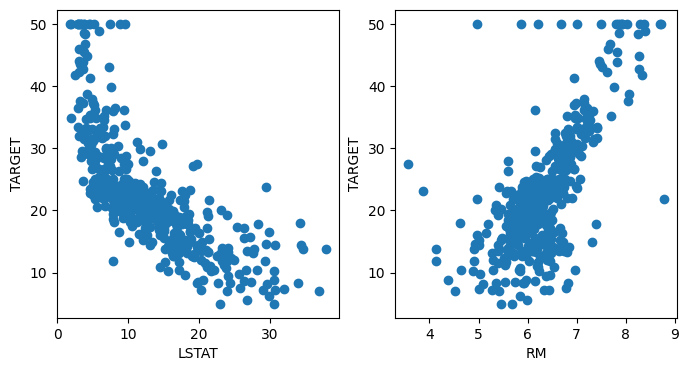

In [11]:
plt.figure(figsize=(8,4))

features = df[["LSTAT","RM"]]
target = df["TARGET"]

plt.subplot(1,2,1)
plt.scatter(features["LSTAT"],target)
plt.xlabel("LSTAT")
plt.ylabel("TARGET")

plt.subplot(1,2,2)
plt.scatter(features["RM"],target)
plt.xlabel("RM")
plt.ylabel("TARGET")

plt.show()

In [12]:
# Splitting the training and testing data

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [13]:
# Import your algorithm

from sklearn.linear_model import LinearRegression


In [14]:
# Create your model

model = LinearRegression()

In [15]:
# Fit your model, test on the testing data, and create a visualization if applicable

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [18]:
intercept = model.intercept_
coefficients = model.coef_

print("Intercept:", intercept)
print("Coefficients:", coefficients)

Intercept: -3.841177079004872
Coefficients: [-0.63249856  5.46509877]


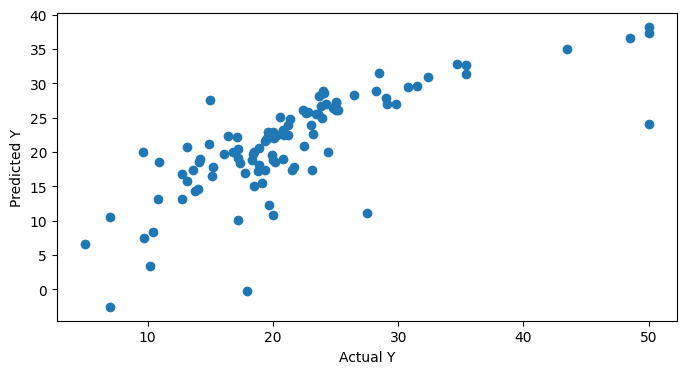

In [17]:
# Create a Visualization

plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Y")
plt.ylabel("Predicted Y")
plt.show()

In [19]:
# Evaluate the models performance

mse = mean_squared_error(y_test, y_pred)
print('Mean Square Error: ', mse)

mae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error: ', mae)

r2 = r2_score(y_test, y_pred)
print('R2:                   ', r2)

Mean Square Error:  31.243290601783634
Mean Absolute Error:  3.8987597213823597
R2:                    0.5739577415025858


In [20]:
# Use the model

new_houses_data ={
    'LSTAT': [5.0,4.0,15.0],
    'RM': [7,6,8]
}

new_houses_df = pd.DataFrame(new_houses_data)
new_houses_df

,LSTAT,RM
0,5.0,7
1,4.0,6
2,15.0,8


In [21]:
predicted_house_prices = model.predict(new_houses_df)
predicted_house_prices

array([31.25202152, 26.41942131, 30.39213466])

In [22]:
new_houses_df['PREDICTED_PRICE'] = predicted_house_prices
new_houses_df

,LSTAT,RM,PREDICTED_PRICE
0,5.0,7,31.252022
1,4.0,6,26.419421
2,15.0,8,30.392135
